In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Tanzania (Dar es Salaam) - Climate Data Analysis

**Station:** Dar es Salaam | **Elevation:** Sea level | **Period:** 2015-2026

Dar es Salaam is a coastal city on the Indian Ocean. Its tropical climate 
features warm temperatures year-round, high humidity, and significant 
seasonal rainfall influenced by monsoon patterns.

In [2]:
df = pd.read_csv('../data/tanzania.csv')
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1,2015
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1,2015
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1,2015
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1,2015
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1,2015


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [4]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/tanzania_clean.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [5]:
print("TANZANIA TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f} C")
print(f"Max T2M: {df_clean['T2M'].max():.1f} C")
print(f"Min T2M: {df_clean['T2M'].min():.1f} C")
print(f"Std Dev: {df_clean['T2M'].std():.1f} C")

heat_days = (df_clean['T2M_MAX'] > 35).sum()
print(f"Days T2M_MAX > 35C: {heat_days} ({heat_days/len(df_clean)*100:.1f}%)")

TANZANIA TEMPERATURE SUMMARY
Mean T2M: 26.8 C
Max T2M: 30.0 C
Min T2M: 22.7 C
Std Dev: 1.3 C
Days T2M_MAX > 35C: 0 (0.0%)


In [6]:
# Outlier Detection using Z-score
print("OUTLIER DETECTION (|Z| > 3):")
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
for col in outlier_cols:
    if col in df_clean.columns:
        z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"  {col}: {outliers} outliers ({(outliers/len(df_clean))*100:.1f}%)")

OUTLIER DETECTION (|Z| > 3):
  T2M: 1 outliers (0.0%)
  T2M_MAX: 2 outliers (0.0%)
  T2M_MIN: 4 outliers (0.1%)
  PRECTOTCORR: 81 outliers (2.0%)
  RH2M: 2 outliers (0.0%)
  WS2M: 8 outliers (0.2%)
  WS2M_MAX: 4 outliers (0.1%)


**Outlier Detection Results:**

The Z-score analysis (|Z| > 3) identified minimal outliers:
- T2M: 1 outlier (0.0%) - Negligible, retained
- T2M_MAX: 2 outliers (0.0%) - Negligible, retained
- T2M_MIN: 4 outliers (0.1%) - Negligible, retained
- PRECTOTCORR: 81 outliers (2.0%) - These represent extreme rainfall events 
  (up to 122.65 mm/day) critical for coastal flood analysis. Retained
- RH2M: 2 outliers (0.0%) - Negligible, retained
- WS2M: 8 outliers (0.2%) - Minor, retained
- WS2M_MAX: 4 outliers (0.1%) - Negligible, retained

**Decision:** All outliers were retained. Tanzania's precipitation outliers 
capture the extreme rainfall events that pose flood risks to coastal Dar es 
Salaam. The ocean-moderated climate produces very stable temperatures with 
almost no temperature outliers, confirming the quality of the dataset.

**Temperature Observations:**

Dar es Salaam's coastal location produces warm, stable temperatures year-round. 
Being at sea level, temperatures are warmer than the highland stations but 
moderated by the Indian Ocean. The low variability indicates minimal seasonal 
temperature changes, typical of equatorial coastal climates.

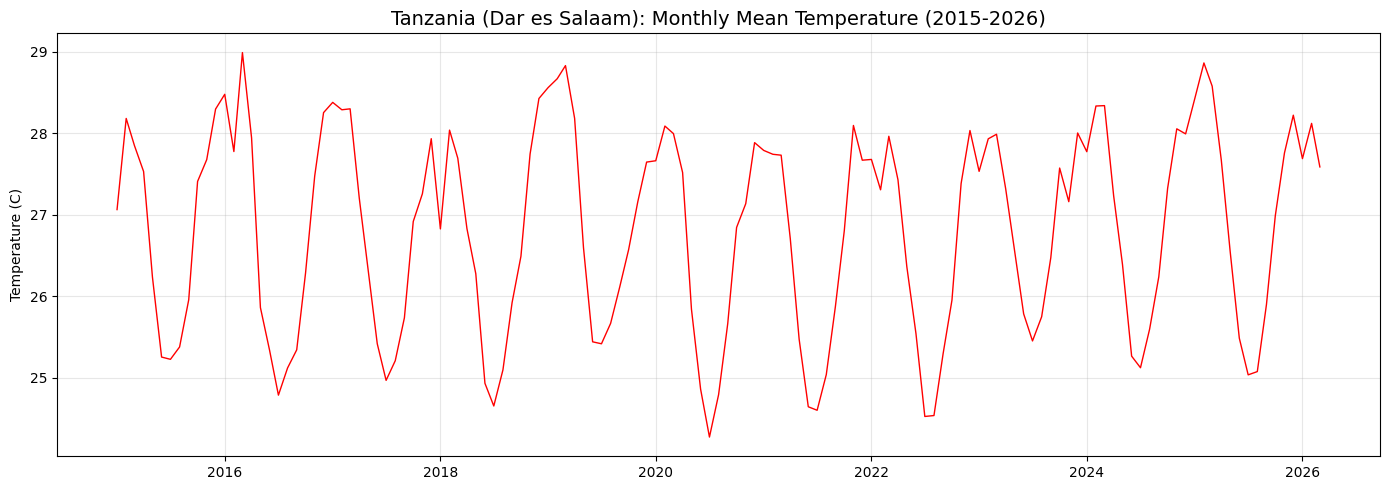

In [7]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Tanzania (Dar es Salaam): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print("TANZANIA PRECIPITATION SUMMARY")
print(f"Mean daily precip: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"Max daily precip: {df_clean['PRECTOTCORR'].max():.2f} mm")
print(f"Days with rain: {(df_clean['PRECTOTCORR'] > 0).sum()} ({(df_clean['PRECTOTCORR'] > 0).sum()/len(df_clean)*100:.0f}%)")
print(f"Days with no rain: {(df_clean['PRECTOTCORR'] == 0).sum()} ({(df_clean['PRECTOTCORR'] == 0).sum()/len(df_clean)*100:.0f}%)")

TANZANIA PRECIPITATION SUMMARY
Mean daily precip: 3.74 mm
Max daily precip: 122.65 mm
Days with rain: 3895 (95%)
Days with no rain: 213 (5%)


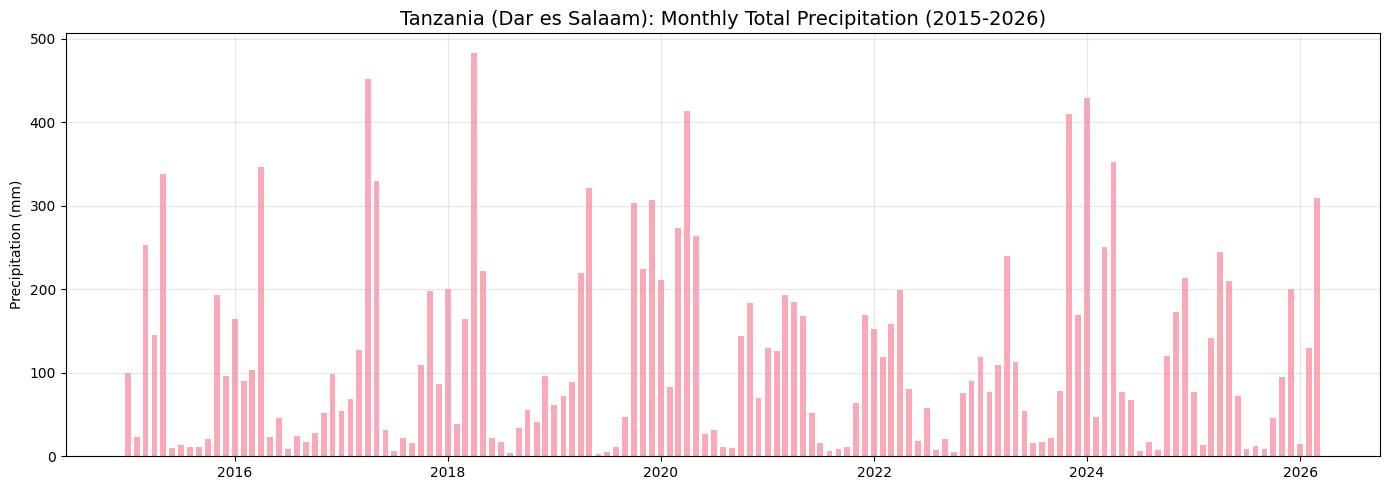

In [9]:
monthly_p = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_p['Date'] = pd.to_datetime(monthly_p[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_p['Date'], monthly_p['PRECTOTCORR'], width=20, alpha=0.6)
plt.title('Tanzania (Dar es Salaam): Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Precipitation Observations:**

Tanzania's coastal location brings significant rainfall with rain on 95% of days. 
The bimodal rainfall pattern is influenced by the movement of the Intertropical 
Convergence Zone (ITCZ) and Indian Ocean monsoon systems. The maximum single-day 
rainfall of 122.65 mm demonstrates the potential for extreme precipitation events 
that can cause urban flooding in Dar es Salaam.

## 3. Seasonal Climatology

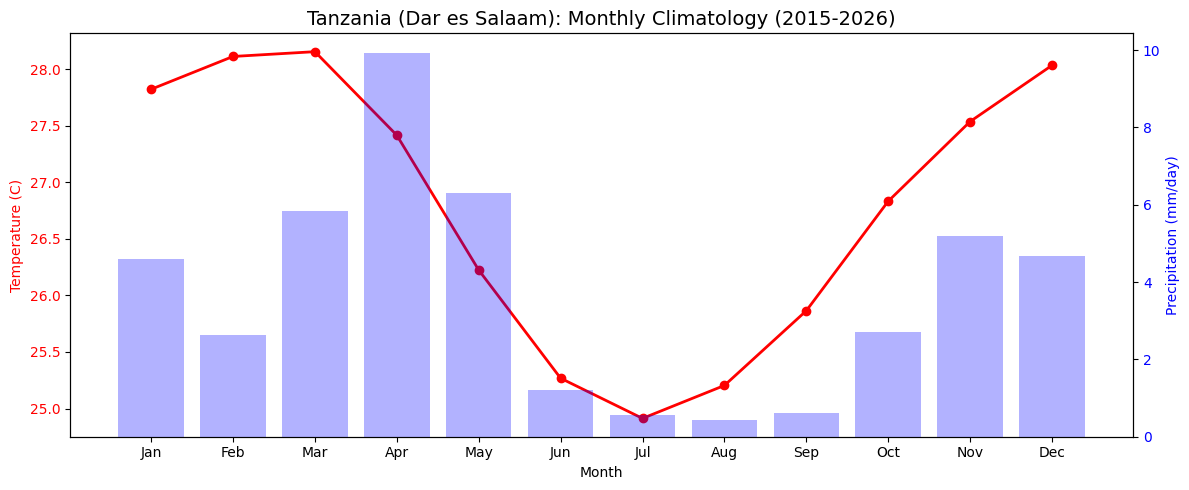

In [10]:
seasonal = df_clean.groupby('Month')[['T2M', 'PRECTOTCORR']].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(seasonal.index, seasonal['T2M'], 'r-o', linewidth=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.bar(seasonal.index, seasonal['PRECTOTCORR'], alpha=0.3, color='blue')
ax2.set_ylabel('Precipitation (mm/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Tanzania (Dar es Salaam): Monthly Climatology (2015-2026)', fontsize=14)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

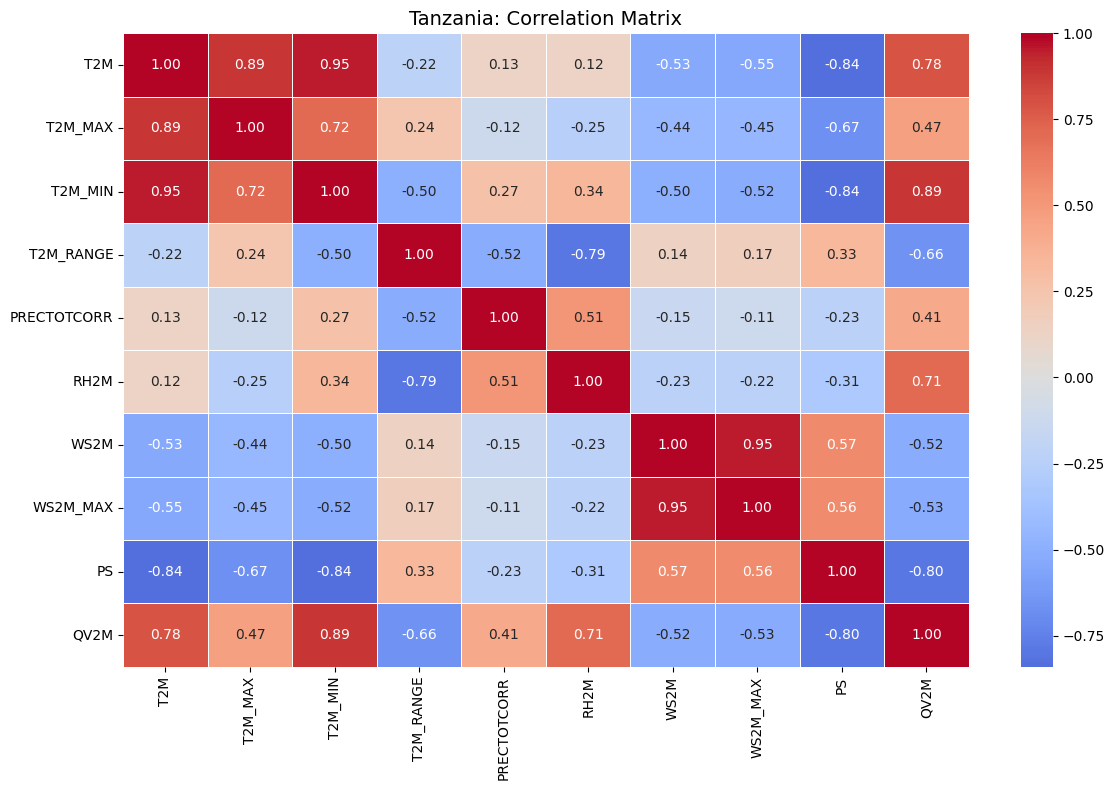

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Tanzania: Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

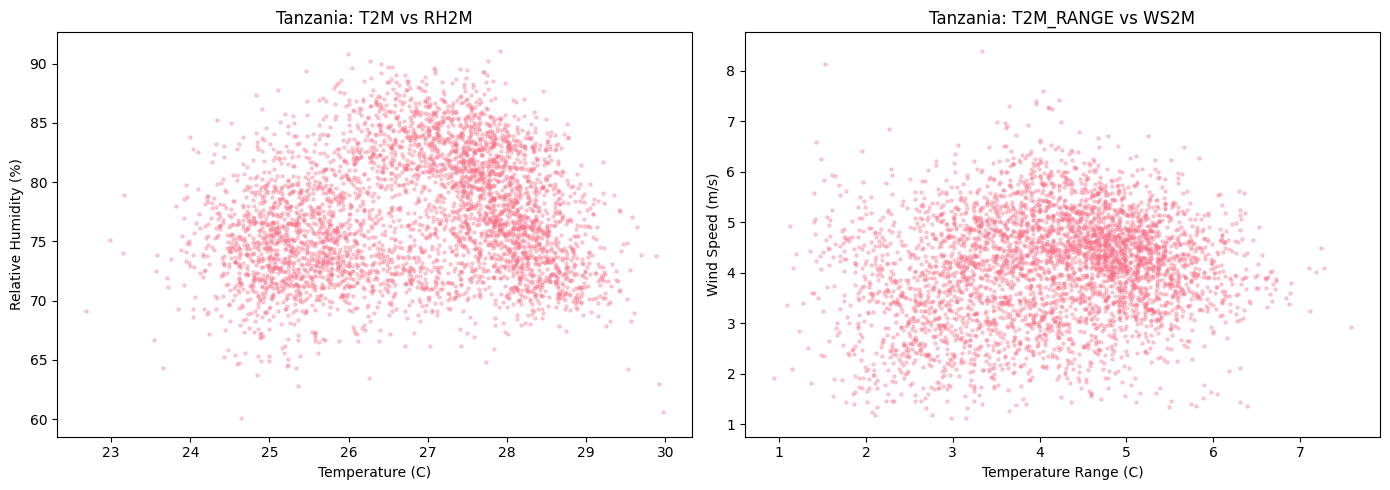

In [12]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['T2M'], df_clean['RH2M'], alpha=0.3, s=5)
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Tanzania: T2M vs RH2M')

axes[1].scatter(df_clean['T2M_RANGE'], df_clean['WS2M'], alpha=0.3, s=5)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Tanzania: T2M_RANGE vs WS2M')

plt.tight_layout()
plt.show()

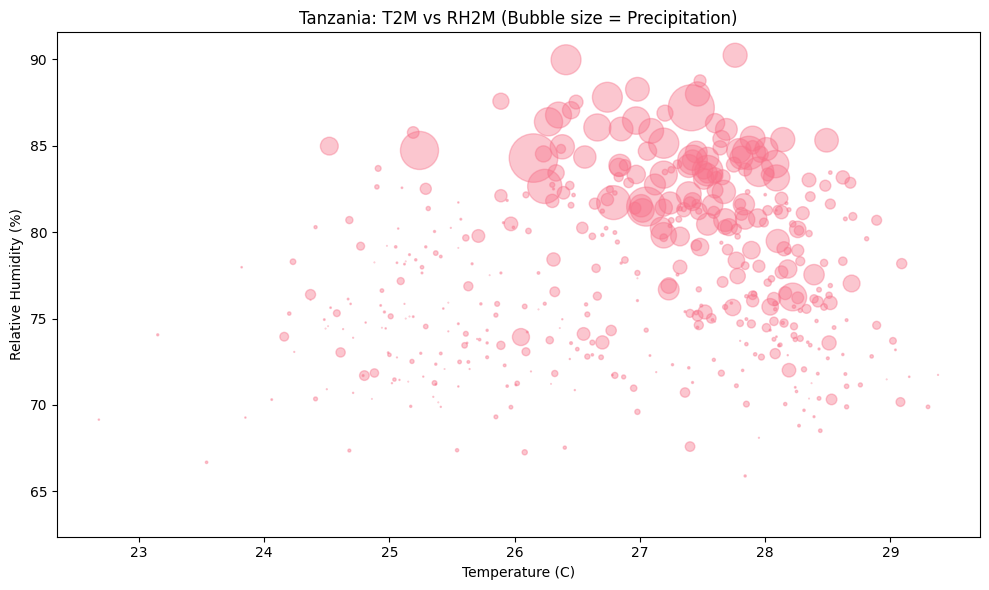

In [13]:
# Bubble chart: T2M vs RH2M, bubble size = precipitation
sample = df_clean.sample(min(500, len(df_clean)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*20, alpha=0.4)
plt.xlabel('Temperature (C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Tanzania: T2M vs RH2M (Bubble size = Precipitation)')
plt.tight_layout()
plt.show()

## 5. Precipitation Distribution

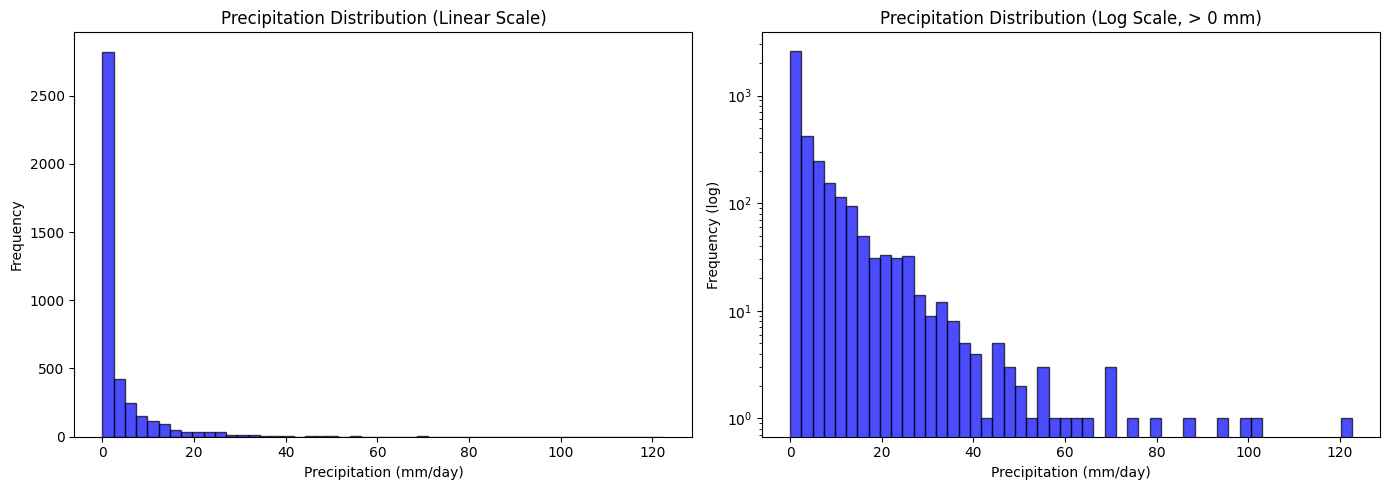

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['PRECTOTCORR'], bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Precipitation Distribution (Linear Scale)')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency')

precip_positive = df_clean['PRECTOTCORR'][df_clean['PRECTOTCORR'] > 0]
axes[1].hist(precip_positive, bins=50, color='blue', alpha=0.7, edgecolor='black', log=True)
axes[1].set_title('Precipitation Distribution (Log Scale, > 0 mm)')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

In [15]:
# Compare with other countries
df_eth = pd.read_csv('../data/ethiopia_clean.csv')
df_ken = pd.read_csv('../data/kenya_clean.csv')
df_sud = pd.read_csv('../data/sudan_clean.csv')

print("=" * 50)
print("FOUR-COUNTRY COMPARISON")
print("=" * 50)
print(f"{'Country':<12} {'Elevation':<12} {'Mean T2M':<10} {'Precip':<10}")
print("-" * 50)
print(f"{'Sudan':<12} {'~400m':<12} {df_sud['T2M'].mean():.1f} C{'':>5} {df_sud['PRECTOTCORR'].mean():.2f} mm")
print(f"{'Tanzania':<12} {'Sea level':<12} {df_clean['T2M'].mean():.1f} C{'':>5} {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"{'Kenya':<12} {'~1,795m':<12} {df_ken['T2M'].mean():.1f} C{'':>5} {df_ken['PRECTOTCORR'].mean():.2f} mm")
print(f"{'Ethiopia':<12} {'~2,355m':<12} {df_eth['T2M'].mean():.1f} C{'':>5} {df_eth['PRECTOTCORR'].mean():.2f} mm")


FOUR-COUNTRY COMPARISON
Country      Elevation    Mean T2M   Precip    
--------------------------------------------------
Sudan        ~400m        28.8 C      0.64 mm
Tanzania     Sea level    26.8 C      3.74 mm
Kenya        ~1,795m      20.4 C      1.47 mm
Ethiopia     ~2,355m      16.1 C      3.63 mm


## Tanzania EDA Complete

Cleaned data saved to: data/tanzania_clean.csv

Tanzania's coastal climate represents the warm, humid end of the spectrum 
among the five countries. With rain on 95% of days and extreme single-day 
rainfall of 122.65 mm, Dar es Salaam faces significant flood risks. The 
stable temperatures (std = 1.3 C) reflect strong ocean moderation, but 
this also means the population is not acclimatized to temperature extremes 
should warming accelerate.